In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("lab3.csv",encoding="latin1")

df["Order Date"] = pd.to_datetime(df["Order Date"])

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


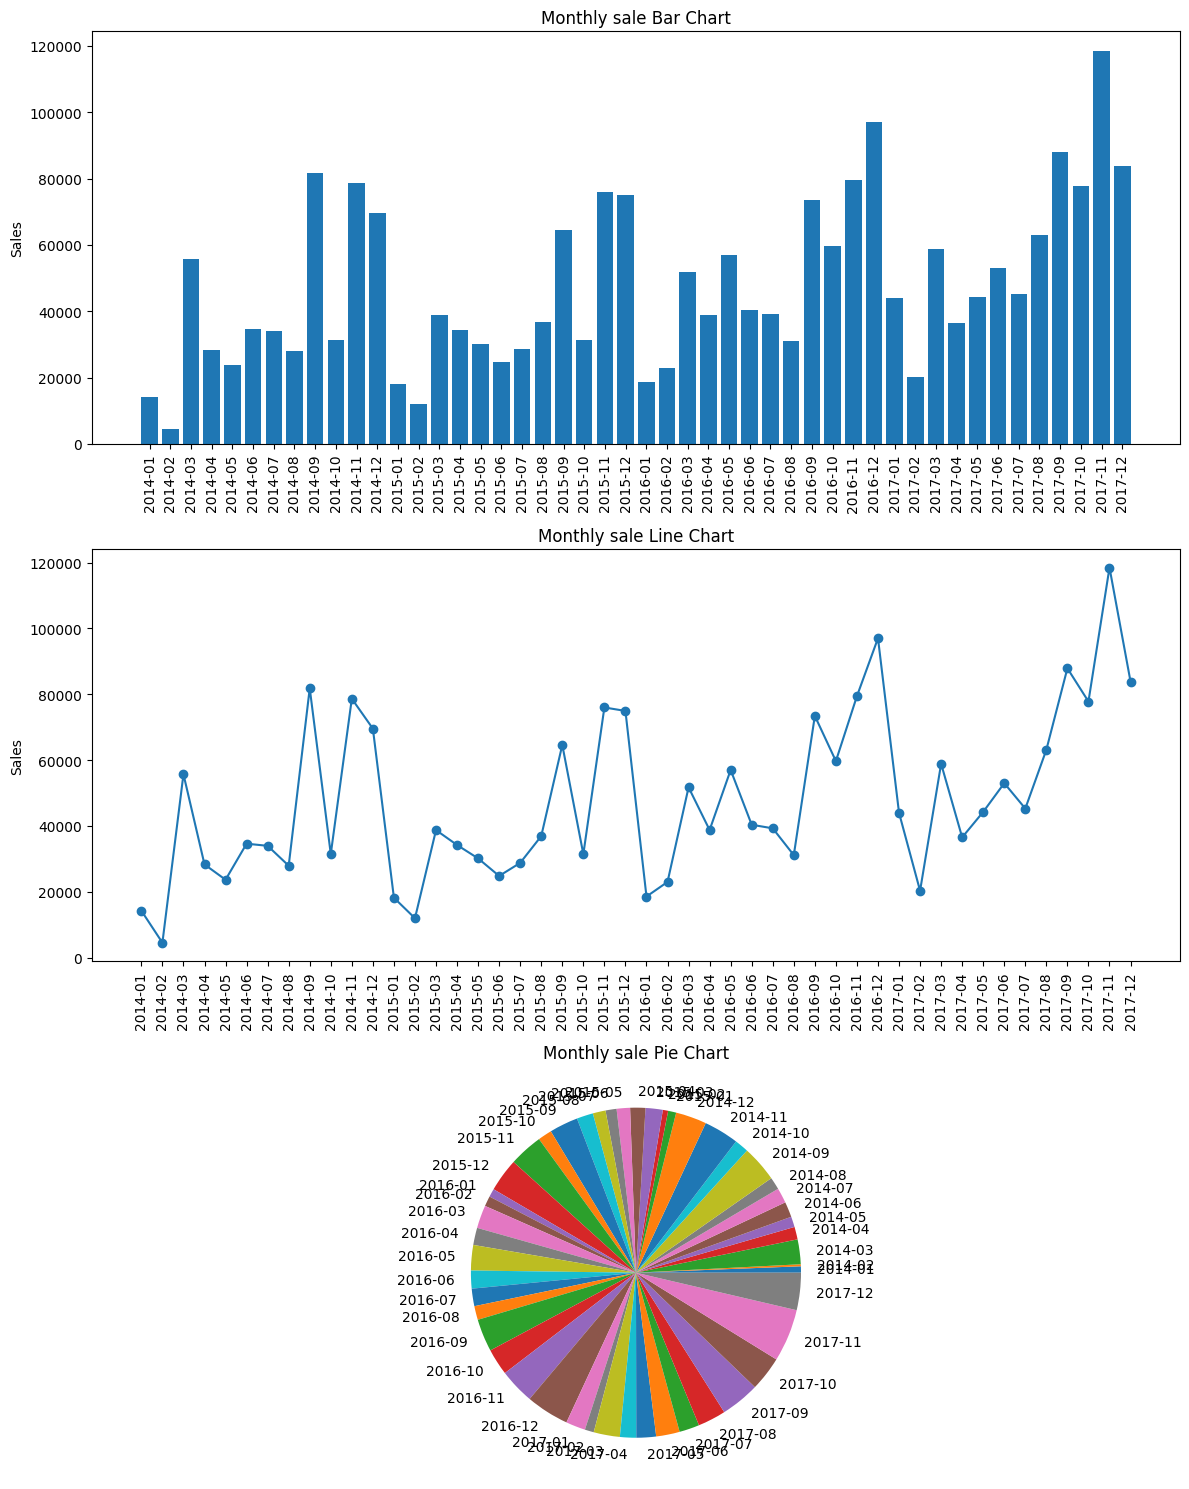

The line chart shows the trend best because it clearly shows changes over time.
The pie chart hides the trend because it does not show the pattern.


In [ ]:
# Task 1
df["Order Date"] = pd.to_datetime(df["Order Date"])
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()
monthly_sales.index = monthly_sales.index.astype(str)

fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# Bar
axes[0].bar(monthly_sales.index, monthly_sales.values)
axes[0].set_title("Monthly sale Bar Chart")
axes[0].set_ylabel("Sales")
axes[0].tick_params(axis="x", rotation=90)

# Line
axes[1].plot(monthly_sales.index, monthly_sales.values, marker="o")
axes[1].set_title("Monthly sale Line Chart")
axes[1].set_ylabel("Sales")
axes[1].tick_params(axis="x", rotation=90)

# Pie
axes[2].pie(monthly_sales.values, labels=monthly_sales.index)
axes[2].set_title("Monthly sale Pie Chart")

plt.tight_layout()
plt.show()

print("The line chart shows the trend best because it clearly shows changes over time.")
print("The pie chart hides the trend because it does not show the pattern.")

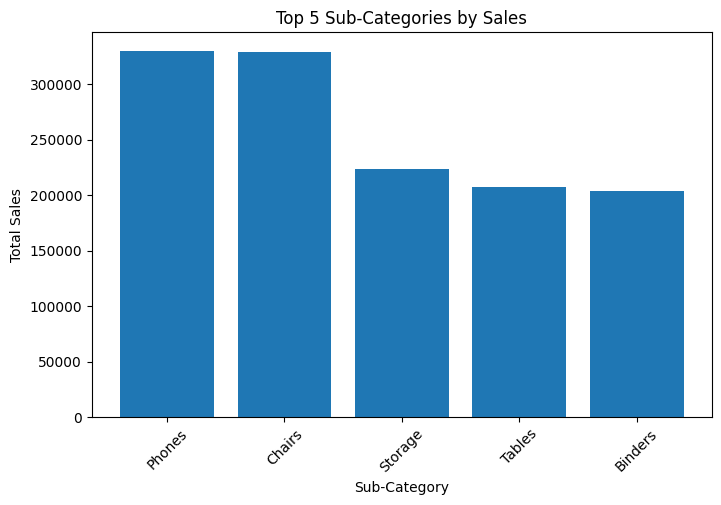

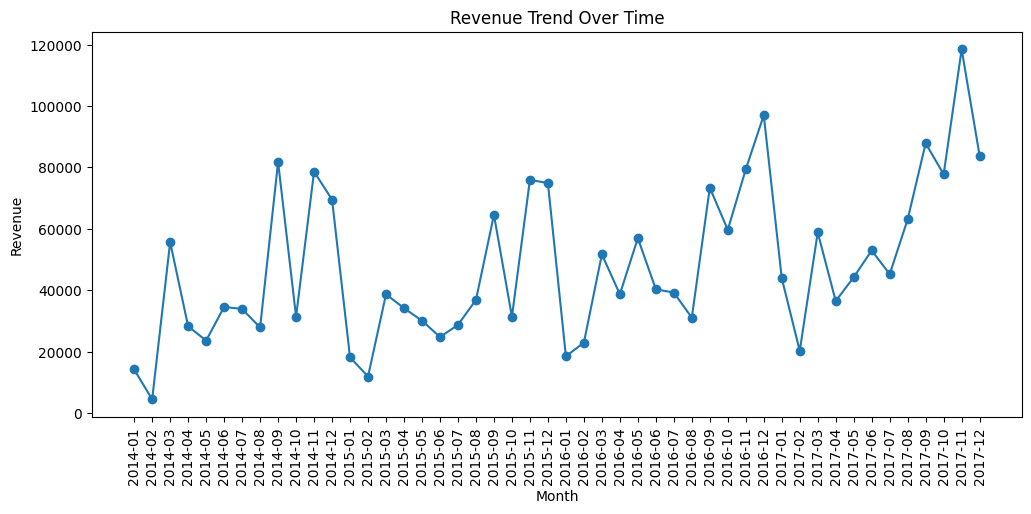

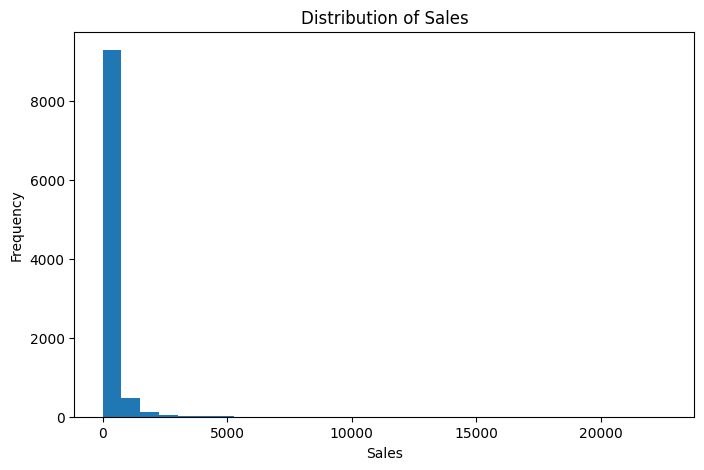

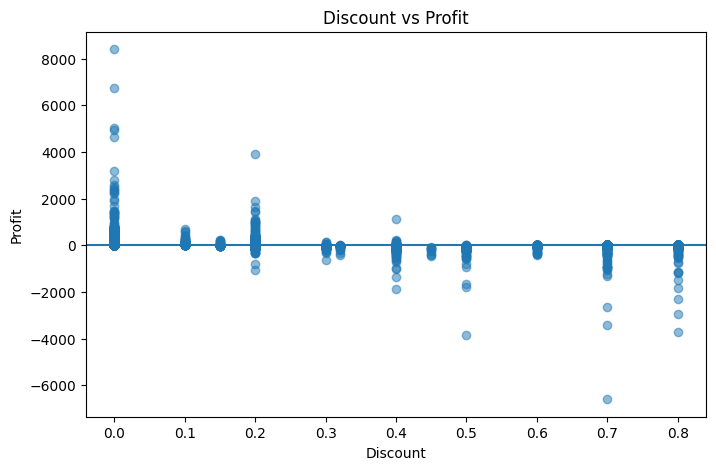

Bar chart: best for comparing categories.
Line chart: best for showing trends over time.
Histogram: best for showing distribution.
Scatter plot: best for showing the relationship between two variables.


In [ ]:
# Task 2


# 1. Compare total sales across top 5 sub-categories
top5 = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8, 5))
plt.bar(top5.index, top5.values)
plt.title("Top 5 Sub-Categories by Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

# 2. Revenue trend over time
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Revenue Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.show()

# 3. Distribution of order line sales
plt.figure(figsize=(8, 5))
plt.hist(df["Sales"], bins=30)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# 4. Discount vs Profit
plt.figure(figsize=(8, 5))
plt.scatter(df["Discount"], df["Profit"], alpha=0.5)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.axhline(0)
plt.show()

print("Bar chart: best for comparing categories.")
print("Line chart: best for showing trends over time.")
print("Histogram: best for showing distribution.")
print("Scatter plot: best for showing the relationship between two variables.")

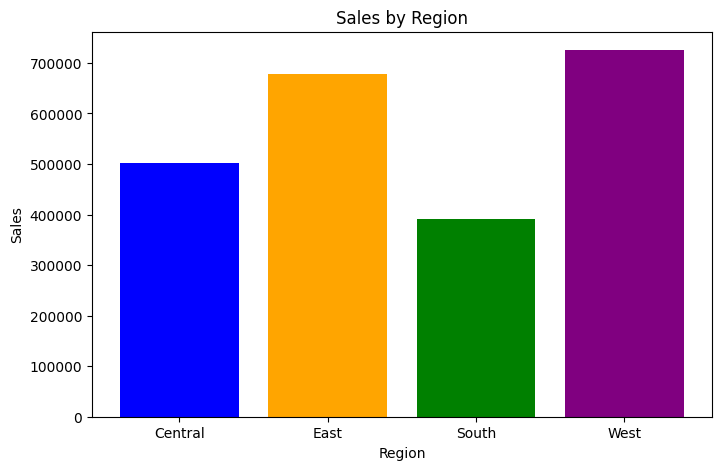

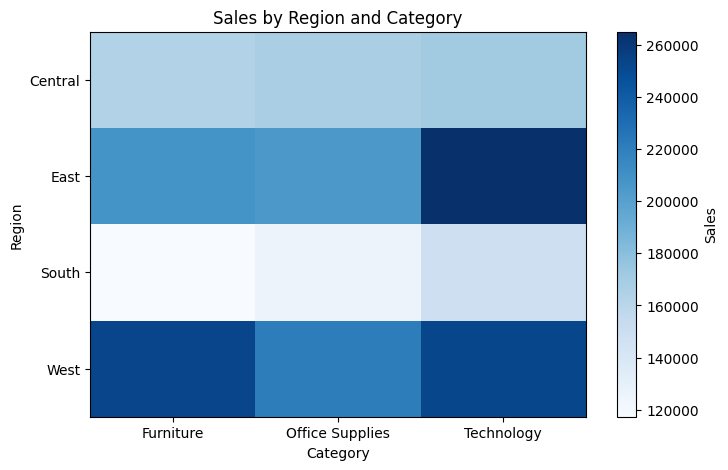

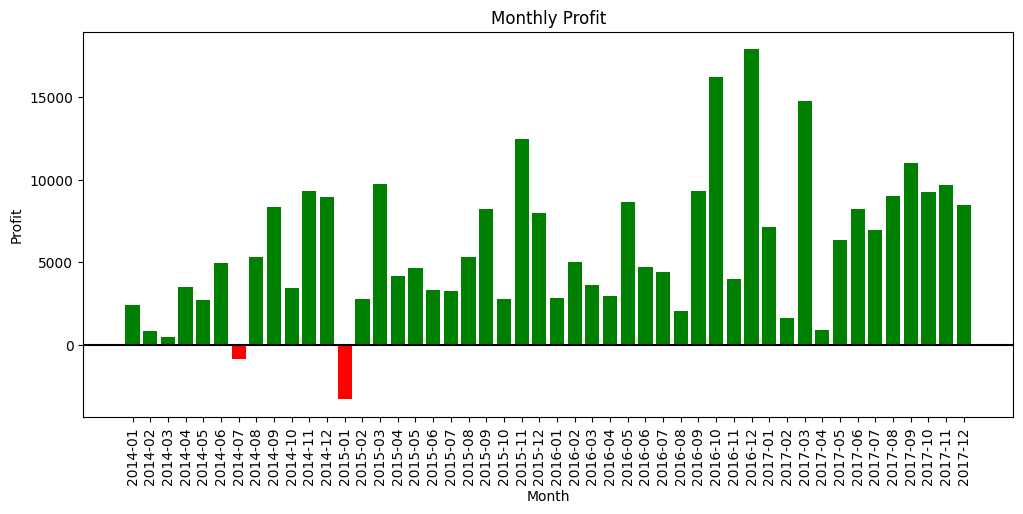

In [ ]:
# Task 3

# A- Sales by region categorical colors
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8, 5))
plt.bar(
    region_sales.index,
    region_sales.values,
    color=["blue", "orange", "green", "purple"]
)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()


# B- Region × Category heatmap sequential palette
region_category = pd.pivot_table(
    df,
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

plt.figure(figsize=(8, 5))
plt.imshow(region_category, cmap="Blues", aspect="auto")
plt.title("Sales by Region and Category")
plt.xlabel("Category")
plt.ylabel("Region")
plt.xticks(range(len(region_category.columns)), region_category.columns)
plt.yticks(range(len(region_category.index)), region_category.index)
plt.colorbar(label="Sales")
plt.show()


# C- Monthly profit diverging colors
monthly_profit = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Profit"].sum()

monthly_profit.index = monthly_profit.index.astype(str)

plt.figure(figsize=(12, 5))
colors = ["red" if x < 0 else "green" for x in monthly_profit.values]

plt.bar(monthly_profit.index, monthly_profit.values, color=colors)
plt.axhline(0, color="black")
plt.title("Monthly Profit")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=90)
plt.show()

Blue : 8.59 PASS
Orange : 1.97 FAIL
Green : 5.14 PASS
Purple : 9.42 PASS


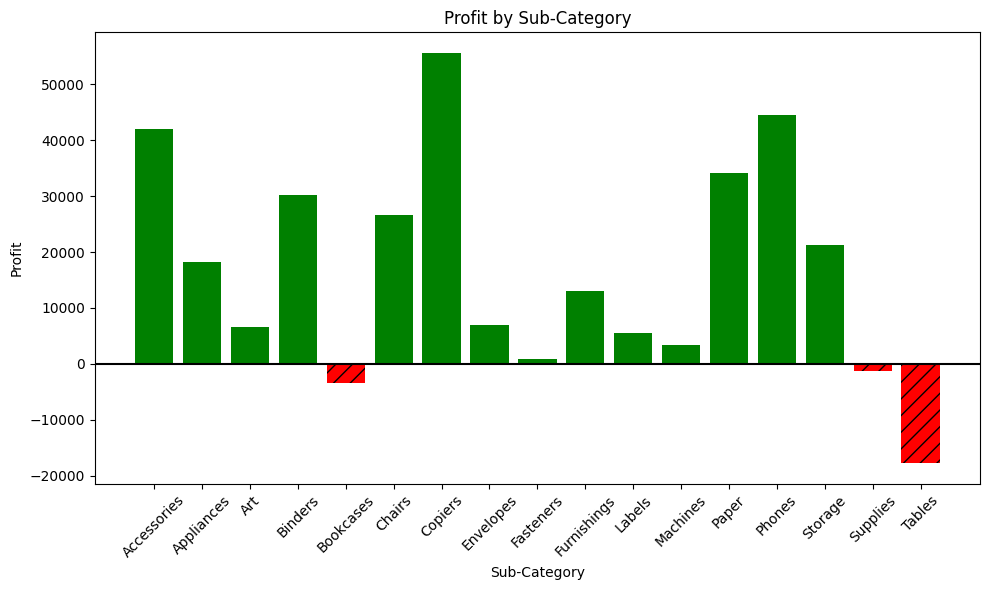

In [ ]:
# Task 4


# WCAG contrast ratio
def contrast_ratio(color1, color2):
    def luminance(color):
        rgb = [x / 255 for x in color]

        rgb = [
            ((x + 0.055) / 1.055) ** 2.4
            if x > 0.04045 else x / 12.92
            for x in rgb
        ]

        return (
            0.2126 * rgb[0] +
            0.7152 * rgb[1] +
            0.0722 * rgb[2]
        )

    L1 = luminance(color1)
    L2 = luminance(color2)

    return (max(L1, L2) + 0.05) / (min(L1, L2) + 0.05)


# Test colors against white
colors = {
    "Blue": (0, 0, 255),
    "Orange": (255, 165, 0),
    "Green": (0, 128, 0),
    "Purple": (128, 0, 128)
}

for name, color in colors.items():
    ratio = contrast_ratio(color, (255, 255, 255))
    print(name, ":", round(ratio, 2),
          "PASS" if ratio >= 4.5 else "FAIL")


# Red/green profit chart
subcategory_profit = df.groupby("Sub-Category")["Profit"].sum()

plt.figure(figsize=(10, 6))

for i, value in enumerate(subcategory_profit):
    if value < 0:
        plt.bar(i, value, color="red", hatch="//")
    else:
        plt.bar(i, value, color="green")

plt.axhline(0, color="black")
plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.xticks(range(len(subcategory_profit)),
           subcategory_profit.index, rotation=45)
plt.tight_layout()
plt.show()


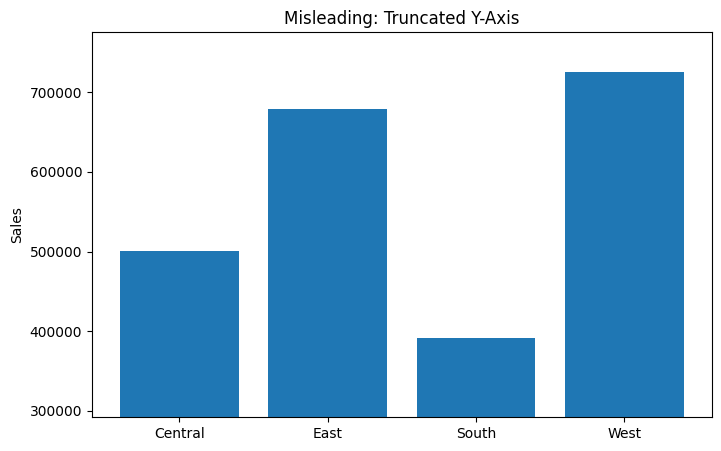

Distortion: Truncated y-axis exaggerates differences between regions.


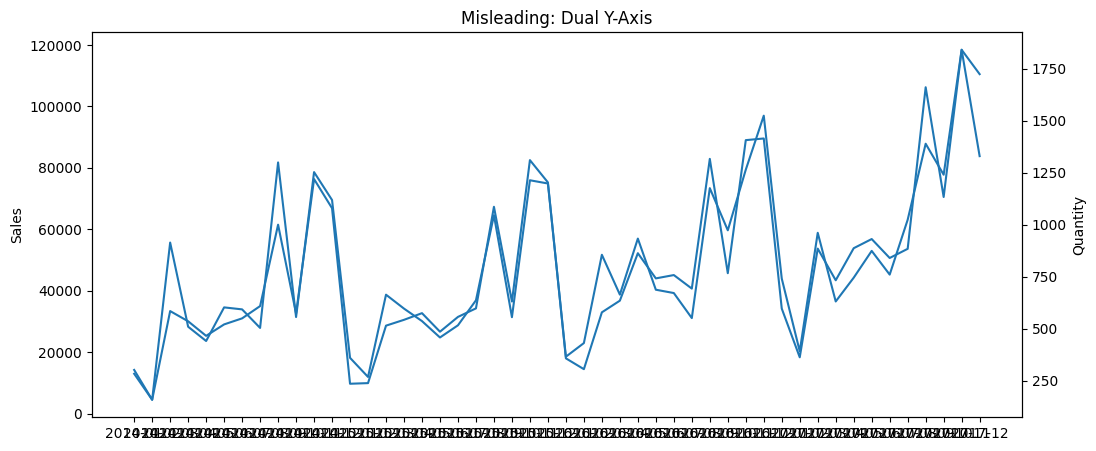

Distortion: Dual y-axes can imply a false correlation between two measures.


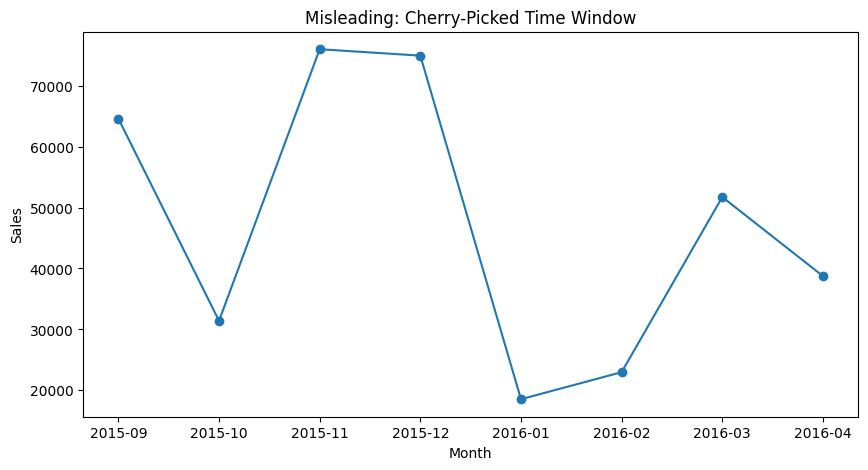

Distortion: Cherry-picked time window hides the surrounding trend.


In [ ]:
# Task 5

# 1. Truncated y axis
plt.figure(figsize=(8, 5))
plt.bar(region_sales.index, region_sales.values)
plt.ylim(region_sales.min() - 100000, region_sales.max() + 50000)
plt.title("Misleading: Truncated Y-Axis")
plt.ylabel("Sales")
plt.show()

print("Distortion: Truncated y axis exaggerates differences between regions.")


# 2. Dual y axis
monthly_quantity = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Quantity"].sum()

monthly_quantity.index = monthly_quantity.index.astype(str)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly_sales.index, monthly_sales.values)
ax1.set_ylabel("Sales")

ax2 = ax1.twinx()
ax2.plot(monthly_quantity.index, monthly_quantity.values)
ax2.set_ylabel("Quantity")

plt.title("Misleading: Dual Y-Axis")
plt.show()

print("Distortion: Dual y-axes can imply a false correlation between two measures.")


# 3. Cherry picked date range
short_period = monthly_sales.iloc[20:28]

plt.figure(figsize=(10, 5))
plt.plot(short_period.index, short_period.values, marker="o")
plt.title("Misleading: Cherry-Picked Time Window")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

print("Distortion: Cherry-picked time window hides the surrounding trend.")

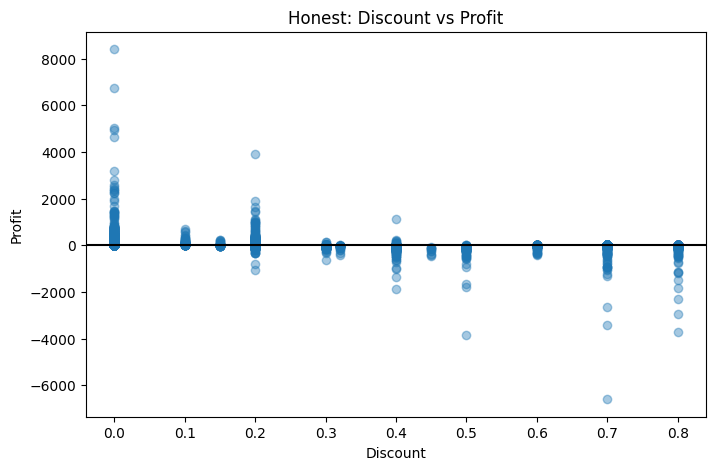

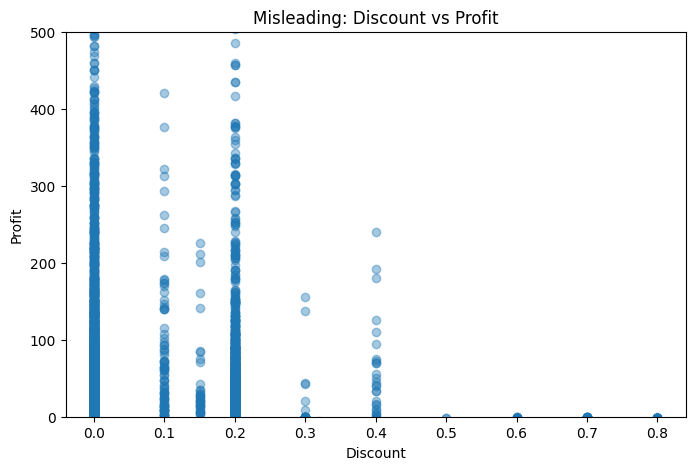

Honest chart ke liay scatter better cuz discount and profit are numeric, shows +ve -ve relationship
neutral colour to prevent misleading view
accessibility, chat doesnt depend on colour only and 0 profit line helps show gains from losses
misleading chart, y axis trunc to 500 hiding -ve profit values which can show profit rather than the loss


In [ ]:
# Task 6

# Is discounting hurting profit?

# HONEST VERSION
plt.figure(figsize=(8, 5))
plt.scatter(df["Discount"], df["Profit"], alpha=0.4)
plt.axhline(0, color="black")
plt.title("Honest: Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()


# MISLEADING VERSION
plt.figure(figsize=(8, 5))
plt.scatter(df["Discount"], df["Profit"], alpha=0.4)
plt.ylim(0, 500)
plt.title("Misleading: Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

print("Honest chart ke liay scatter better cuz discount and profit are numeric, shows +ve -ve relationship")
print("neutral colour to prevent misleading view")
print("accessibility, chat doesnt depend on colour only and 0 profit line helps show gains from losses")
print("misleading chart, y axis trunc to 500 hiding -ve profit values which can show profit rather than the loss")